In [1]:
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes jax is installed
#!pip install bayesflow
import bayesflow as bf

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:2026-05-25 16:35:57,771:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## Helper Functions

In [2]:
LOW = -3.0
HIGH = 3.0
SHIFT = 1.0
SIGMA_NOISE = 0.2


def prior(rng=None):
    rng = np.random.default_rng(rng)
    theta = rng.uniform(LOW, HIGH, size=2)
    return {"parameters": theta}


def mixture(parameters, rng=None, num_distractors=2):
    rng = np.random.default_rng(rng)

    theta = parameters

    mode = rng.integers(0, 2)
    sign = 1.0 if mode == 0 else -1.0

    y_informative = rng.normal(loc=theta + sign * SHIFT, scale=SIGMA_NOISE, size=2)
    y_distractors = rng.uniform(LOW, HIGH, size=num_distractors)

    y = np.concatenate([y_informative, y_distractors])

    return {"obs": y}

def sample_ground_truth_posterior(n_samples, rng=None):
    """Ground-truth posterior for y_o = zeros(20).

    Equivalent to:
    GaussianMixture(dim=2, mu=[-1., 1.], sigma=[0.2, 0.2], weights=[0.5, 0.5])
    """
    rng = np.random.default_rng(rng)

    modes = rng.integers(0, 2, size=n_samples)
    means = np.where(modes[:, None] == 0, -SHIFT, SHIFT)

    samples = rng.normal(loc=means, scale=SIGMA_NOISE, size=(n_samples, 2))

    return samples


def plot_posteriors(samples_gt, results, figsize=None):
    num_distractors_list = list(results.keys())
    n_plots = 1 + len(num_distractors_list)
    n_cols = int(np.ceil(n_plots / 2))
    if figsize is None:
        figsize = (4 * n_cols, 8)

    f, axes = plt.subplots(2, n_cols, figsize=figsize)
    axes = axes.flatten()

    # Ground truth
    axes[0].scatter(samples_gt[:, 0], samples_gt[:, 1], color="gray", label="True", s=10)
    axes[0].set_xlabel(r"$\theta_1$", fontsize=16)
    axes[0].set_ylabel(r"$\theta_2$", fontsize=16)
    axes[0].set_title("Ground Truth", fontsize=13)
    axes[0].legend(fontsize=12)
    sns.despine(ax=axes[0])

    # Approximate posteriors
    for ax, nd in zip(axes[1:], num_distractors_list):
        r = results[nd]
        ax.scatter(r["samples"][:, 0], r["samples"][:, 1], color="purple", alpha=0.5, s=10, label="Approx")
        ax.set_xlabel(r"$\theta_1$", fontsize=16)
        ax.set_title(
            f"Distractors: {nd}, t={r['runtime']:.3f}s\nC2ST: {r['c2st']:.3f}",
            fontsize=14
        )
        sns.despine(ax=ax)

    # Hide any unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    f.tight_layout()
    return f

In [3]:
# Bayesflow-compatible simulator
simulator = bf.make_simulator([prior, mixture])

# Ground-truth "observation"
obs_true = np.zeros((1,2))

# Ground truth posterior samples
samples_gt = sample_ground_truth_posterior(1000)

## BayesFlow Training

In [4]:
num_distractors_list = [3, 8, 13, 18]
results = {}

for num_distractors in num_distractors_list:
    
    # Training data and observable test point
    train_data = simulator.sample(20_000, num_distractors=num_distractors)
    val_data = simulator.sample(500, num_distractors=num_distractors)
    obs_dist = np.random.uniform(LOW, HIGH, size=(1, num_distractors))
    obs = np.concatenate((obs_true, obs_dist), axis=1)

    # Simple BayesFlow workflow with timing
    workflow = bf.BasicWorkflow(
        inference_network=bf.networks.FlowMatching(subnet_kwargs={"widths":(128,)*3}),
        inference_variables=["parameters"],
        inference_conditions=["obs"],
    )

    # Traing without spamming progress bar
    t_start = perf_counter()
    history = workflow.fit_offline(
        train_data, epochs=120, batch_size=256, validation_data=val_data, verbose=0
    )
    runtime = perf_counter() - t_start

    # Obtain 1000 samples
    samples_bf = workflow.sample(conditions={"obs": obs}, num_samples=1000)
    samples_bf = samples_bf["parameters"][0]

    # Classifier-2-sample test
    c2st = bf.diagnostics.metrics.classifier_two_sample_test(samples_bf, samples_gt)

    results[num_distractors] = {
        "samples": samples_bf,
        "c2st": c2st,
        "runtime": runtime
    }

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:bayesflow:Training completed in 1.47 minutes.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.38 seconds.
INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:bayesflow:Training completed in 1.17 minutes.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.22 seconds.
INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:bayesflow:Training completed in 2.09 minutes.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.57 seconds.
INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:bayesflow:Training completed in 2.19 minutes.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.60 seconds.


## Quick Eval

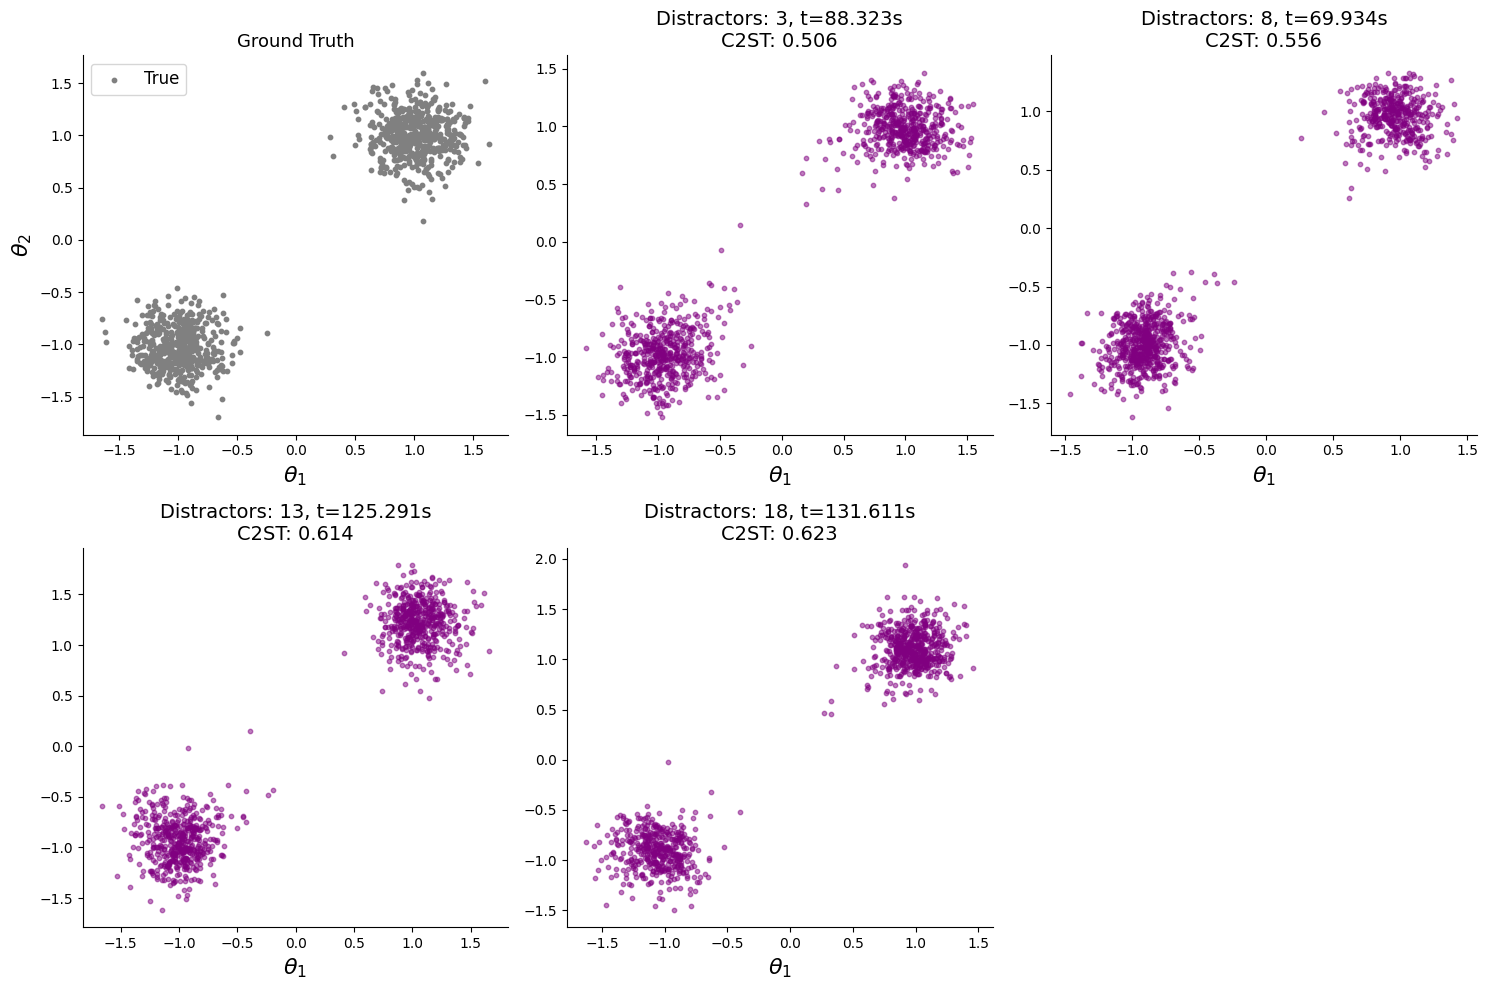

In [5]:
f = plot_posteriors(samples_gt, results, figsize=(15, 10))

## Just for Fun: 1000 Distractors

In [6]:
# Training data and observable test point
train_data = simulator.sample(100_000, num_distractors=1000)
val_data = simulator.sample(500, num_distractors=1000)
obs_dist = np.random.uniform(LOW, HIGH, size=(1, 1000))
obs = np.concatenate((obs_true, obs_dist), axis=1)
results_fun = {}

# Simple BayesFlow workflow with timing

workflow = bf.BasicWorkflow(
    inference_network=bf.networks.FlowMatching(
        subnet_kwargs={"widths":(64,)*3, "dropout": 0.5}
    ),
    inference_variables=["parameters"],
    inference_conditions=["obs"],
)

# Traing without spamming progress bar
t_start = perf_counter()
history = workflow.fit_offline(
    train_data, epochs=120, batch_size=256, validation_data=val_data, verbose=2
)
runtime = perf_counter() - t_start

# Obtain 1000 samples
samples_bf = workflow.sample(conditions={"obs": obs}, num_samples=1000)
samples_bf = samples_bf["parameters"][0]

# Classifier-2-sample test
c2st = bf.diagnostics.metrics.classifier_two_sample_test(samples_bf, samples_gt)

results_fun = {
    "samples": samples_bf,
    "c2st": c2st,
    "runtime": runtime
}

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/120
391/391 - 7s - 17ms/step - loss: 2.8665 - val_loss: 2.0580
Epoch 2/120
391/391 - 2s - 6ms/step - loss: 2.1241 - val_loss: 1.9174
Epoch 3/120
391/391 - 2s - 6ms/step - loss: 1.8036 - val_loss: 1.3806
Epoch 4/120
391/391 - 2s - 6ms/step - loss: 1.2935 - val_loss: 0.9655
Epoch 5/120
391/391 - 2s - 6ms/step - loss: 0.9349 - val_loss: 0.7710
Epoch 6/120
391/391 - 3s - 8ms/step - loss: 0.7879 - val_loss: 0.7321
Epoch 7/120
391/391 - 4s - 11ms/step - loss: 0.7094 - val_loss: 0.7348
Epoch 8/120
391/391 - 3s - 9ms/step - loss: 0.6589 - val_loss: 0.6684
Epoch 9/120
391/391 - 4s - 11ms/step - loss: 0.6209 - val_loss: 0.6771
Epoch 10/120
391/391 - 4s - 10ms/step - loss: 0.6006 - val_loss: 0.6027
Epoch 11/120
391/391 - 5s - 13ms/step - loss: 0.5855 - val_loss: 0.6350
Epoch 12/120
391/391 - 5s - 14ms/step - loss: 0.5671 - val_loss: 0.5875
Epoch 13/120
391/391 - 5s - 14ms/step - loss: 0.5495 - val_loss: 0.5976
Epoch 14/120
391/391 - 5s - 14ms/step - loss: 0.5360 - val_loss: 0.5479
Epoch 1

INFO:bayesflow:Training completed in 6.72 minutes.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.46 seconds.


In [ ]:
results_fun["c2st"]

0.7499999880790711